In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
np.set_printoptions(legacy='1.25')

h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e

In [2]:
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 0, 0
l1_1, l2_1 = 1, 1
j1_0, j2_0 = 1/2, 1/2


if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()
   
n_dif = 3
jdif = 3
ldif = 3
b=0
energy_unit = 'MHz'
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

    n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  n2_1  l2_1  j2_1  \
0     45     0   0.5    47     0   0.5    45     1   1.5    46     1   1.5   
1     46     0   0.5    48     0   0.5    46     1   1.5    47     1   1.5   
2     48     0   0.5    51     0   0.5    48     1   1.5    50     1   0.5   
3     59     0   0.5    57     0   0.5    58     1   0.5    57     1   0.5   
4     61     0   0.5    65     0   0.5    61     1   0.5    64     1   0.5   
5     68     0   0.5    67     0   0.5    67     1   0.5    67     1   1.5   
6     69     0   0.5    68     0   0.5    68     1   0.5    68     1   1.5   
7     71     0   0.5    69     0   0.5    70     1   1.5    69     1   0.5   
8     72     0   0.5    70     0   0.5    71     1   1.5    70     1   0.5   
9     72     0   0.5    75     0   0.5    72     1   0.5    74     1   1.5   
10    73     0   0.5    76     0   0.5    73     1   0.5    75     1   1.5   
11    77     0   0.5    81     0   0.5    77     1   1.5    80  

In [3]:
channel = 3
c = channels.loc[channel]
# set atom properties
n1, l1, j1 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2, l2, j2 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 

l1_1, l2_1 = int(c['l1_1']), int(c['l2_1'])

btunes = magTune_import(atom1, n1, l1, j1, atom2, n2, l2, j2, l1_1, l2_1)
b_index = 0
bmax = max(btunes)
    
theta, phi = 0, 0
dn = 3
deltamax = 1e12

n1_0, n2_0 = channels['n1_0'][channel], channels['n2_0'][channel]
n1_1, n2_1 = channels['n1_1'][channel], channels['n2_1'][channel]
j1_1, j2_1 = channels['j1_1'][channel], channels['j2_1'][channel]

m1_0s, m2_0s = np.arange(-j1_0, j1_0 + 1), np.arange(-j2_0, j2_0 + 1)
m1_i, m2_i = 0, 0


m1_1s, m2_1s = np.arange(-j1_1, j1_1 + 1), np.arange(-j2_1, j2_1 + 1)
m1_1i, m2_1i = 0, 0
print(m2_1s)
# Angular plots of C6
ns = np.arange(30,110,1)

# Defining pairinteraction kets
ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=m1_0s[m1_i], j=j1_0)
ket1basis = pi.BasisAtom(atom1, n=(ket1.n,ket1.n), l=(ket1.l,ket1.l), j=(ket1.j,ket1.j))

ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=m2_0s[m2_i], j=j2_0)
ket2basis = pi.BasisAtom(atom2, n=(ket2.n,ket2.n), l=(ket2.l,ket2.l), j=(ket2.j,ket2.j))

ket1_energy = ket1.get_energy(unit=energy_unit)
basis1 = pi.BasisAtom(atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

ket2_energy = ket2.get_energy(unit=energy_unit)
basis2 = pi.BasisAtom(atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif,ket2.j+jdif))

ket1_1, ket2_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=m1_1s[m1_1i]), pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1,  m=m2_1s[m2_1i])
ket1_1basis = pi.BasisAtom(atom1, n=(ket1_1.n,ket1_1.n), l=(ket1_1.l,ket1_1.l), j=(ket1_1.j,ket1_1.j))
ket2_1basis = pi.BasisAtom(atom2, n=(ket2_1.n,ket2_1.n), l=(ket2_1.l,ket2_1.l), j=(ket2_1.j,ket2_1.j))

print(ket2basis.kets)

[-0.5  0.5]
[KetAtom(Cs:57,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,1/2)]


In [4]:
# setting target and resonant states
ket0_tuples = []
ket1_tuples = []
for ket1 in ket1basis.kets:
    for ket2 in ket2basis.kets:
         ket0_tuples.append((ket1, ket2))
for ket1_1 in ket1_1basis.kets:
    for ket2_1 in ket2_1basis.kets: 
        ket1_tuples.append((ket1_1, ket2_1))
print(len(ket0_tuples))

tuple0 = ket0_tuples[0]
tuple1 = ket1_tuples[0]

deltaM = tuple1[0].m + tuple1[1].m - tuple0[0].m - tuple0[1].m

ket_tuples = (tuple0, tuple1)

print(deltaM, ket_tuples)


4
0.0 ((KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,-1/2)), (KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Cs:57,P_1/2,-1/2)))


In [5]:
ket_tuples = []
for tuple0 in ket0_tuples:
    ket_tuples.append(tuple0)
eff_system = pi.EffectiveSystemPair(ket_tuples)
print(ket_tuples)


rs = [5, 10, 15, 20, 25, 5000]
thetas = [0, 45, 90]
bs = np.linspace(0, bmax+2, 500)

datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\magnetic\\target state hams\\'
if not os.path.exists(datapath):
    os.makedirs(datapath)
    
for theta in thetas:
    for r in rs:  

        eff_h_dict_elements = {'bs' : bs}

        if not os.path.exists(datapath + f'theta {theta}, sep {r}um1.csv'):
            
            eff_system = eff_system.set_distance(r, angle_degree=theta, unit="micrometer")
            eff_system.set_diamagnetism_enabled(True)
            
            pair_energy_pm = eff_system.get_pair_energies("MHz")[0]

            for i in range(len(ket_tuples)):
                for j in range(len(ket_tuples)):
                    
                    eff_h_dict_elements.update({f'{i}{j}' : []})
            for mag in bs:

                eff_system = eff_system.set_magnetic_field([0,0,mag], unit="G")
                eff_system.set_maximum_number_of_ket_pairs(100)
                pair_energy_pm = eff_system.get_pair_energies("MHz")[0]

                H = eff_system.get_effective_hamiltonian(unit="MHz") - pair_energy_pm * np.eye(len(ket_tuples))

                for i in range(len(ket_tuples)):
                    for j in range(len(ket_tuples)):
                        eff_h_dict_elements[f'{i}{j}'].append(H[i,j])

            pd.DataFrame(eff_h_dict_elements).to_csv(datapath + f'theta {theta}, sep {r}um.csv', index = False)



[(KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,-1/2)), (KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,1/2)), (KetAtom(Rb:59,S_1/2,1/2), KetAtom(Cs:57,S_1/2,-1/2)), (KetAtom(Rb:59,S_1/2,1/2), KetAtom(Cs:57,S_1/2,1/2))]


The ket |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,-1/2⟩ has only 0.612 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:58,P_1/2,-1/2; Cs:57,P_1/2,-1/2⟩ with overlap 7.908e-01
The ket |Rb:59,S_1/2,-1/2; Cs:57,S_1/2,1/2⟩ has only 0.480 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most perturbing states are:
  - |Rb:58,P_1/2,-1/2; Cs:57,P_1/2,1/2⟩ with overlap 6.203e-01
  - |Rb:58,P_1/2,1/2; Cs:57,P_1/2,-1/2⟩ with overlap 6.203e-01
The ket |Rb:59,S_1/2,1/2; Cs:57,S_1/2,-1/2⟩ has only 0.480 overlap with its corresponding effective eigenvector.
 Thus, the calculation might lead to unexpected or wrong results.
 Consider adding the most perturbing states to the model space.
 The most pert

In [7]:
H = {f'{r}{theta}' : pd.read_csv(datapath + f'theta {theta}, sep {r}um.csv') for r in rs for theta in thetas}
print(H)
matrix_lists = {f'{r}{theta}' : [[[H[f'{r}{theta}'][f'{i}{j}'][k] for i in range(len(ket_tuples))] for j in range(len(ket_tuples))] for k in range(len(H[f'{r}{theta}']))] for r in rs for theta in thetas}

eval_list = {f'{r}{theta}' : [np.linalg.eigh(matrix)[0] for matrix in matrix_lists[f'{r}{theta}']] for r in rs for theta in thetas}
evec_list = {f'{r}{theta}' : [np.linalg.eigh(matrix)[1] for matrix in matrix_lists[f'{r}{theta}']] for r in rs for theta in thetas}
bs = {f'{r}{theta}' : H[f'{r}{theta}']['bs'] for r in rs for theta in thetas}

{'50':             bs         00   01   02   03   10          11         12   13  \
0     0.000000  21.481146  0.0  0.0  0.0  0.0   42.962343  42.962393  0.0   
1     0.040615  21.584117  0.0  0.0  0.0  0.0   43.079345  42.962387  0.0   
2     0.081230  21.688035  0.0  0.0  0.0  0.0   43.196339  42.962372  0.0   
3     0.121844  21.792911  0.0  0.0  0.0  0.0   43.313322  42.962345  0.0   
4     0.162459  21.898758  0.0  0.0  0.0  0.0   43.430295  42.962310  0.0   
..         ...        ...  ...  ...  ...  ...         ...        ...  ...   
495  20.104321 -20.422685  0.0  0.0  0.0  0.0   99.625798  41.722352  0.0   
496  20.144936 -20.357217  0.0  0.0  0.0  0.0   99.737773  41.717471  0.0   
497  20.185551 -20.292222  0.0  0.0  0.0  0.0   99.849738  41.712580  0.0   
498  20.226165 -20.227697  0.0  0.0  0.0  0.0   99.961694  41.707682  0.0   
499  20.266780 -20.163635  0.0  0.0  0.0  0.0  100.073641  41.702775  0.0   

      20         21         22   23   30   31   32          33  
0  

0 (KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,-1/2))
1 (KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,1/2))
2 (KetAtom(Rb:59,S_1/2,1/2), KetAtom(Cs:57,S_1/2,-1/2))
3 (KetAtom(Rb:59,S_1/2,1/2), KetAtom(Cs:57,S_1/2,1/2))


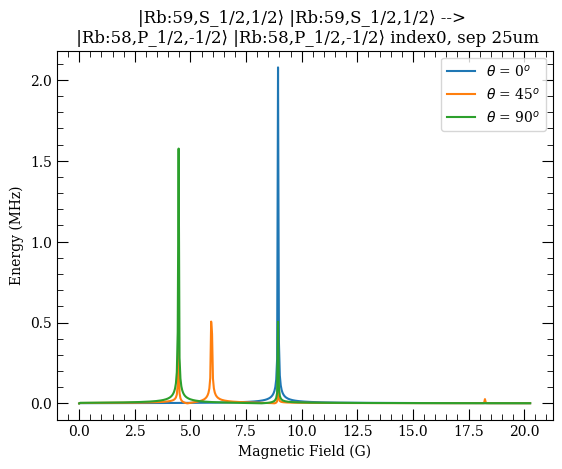

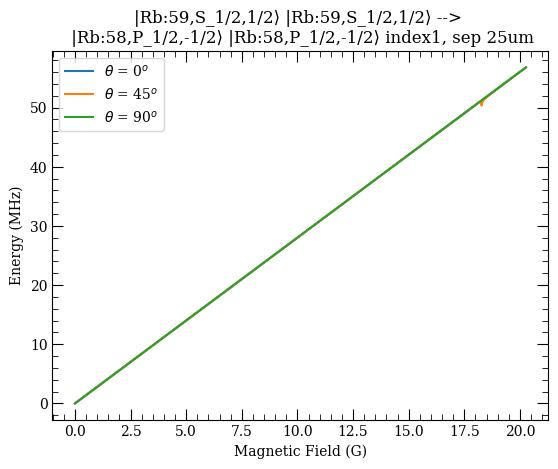

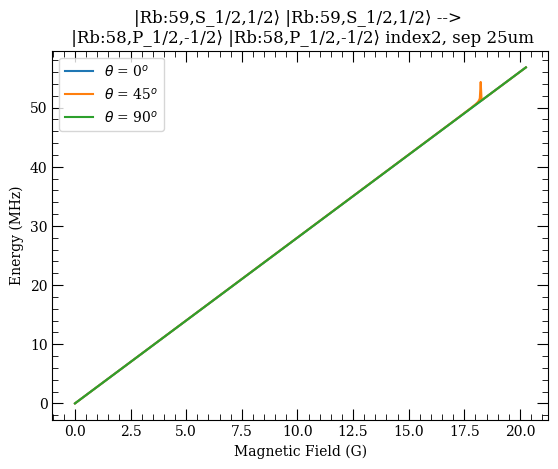

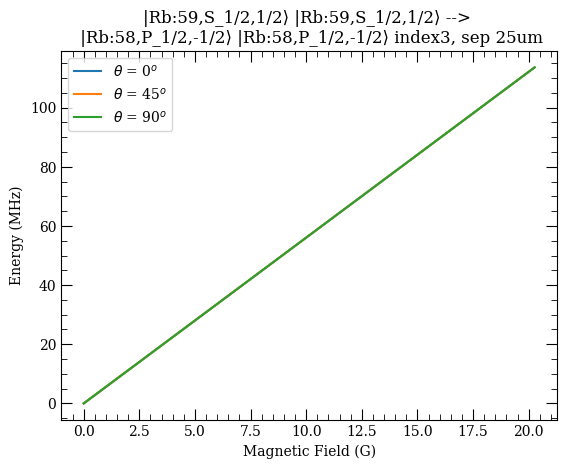

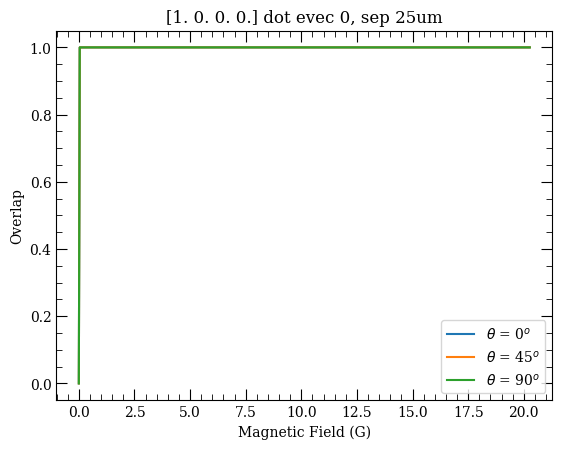

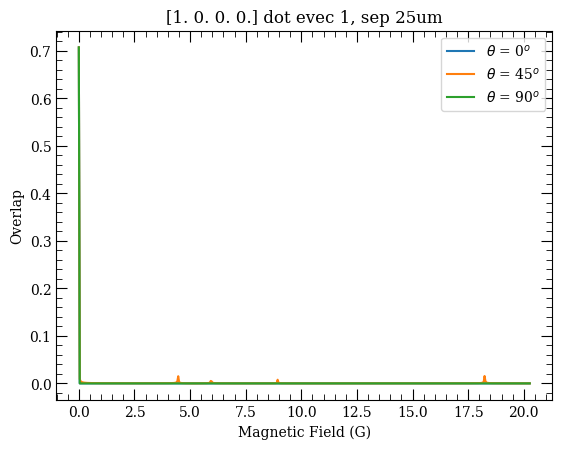

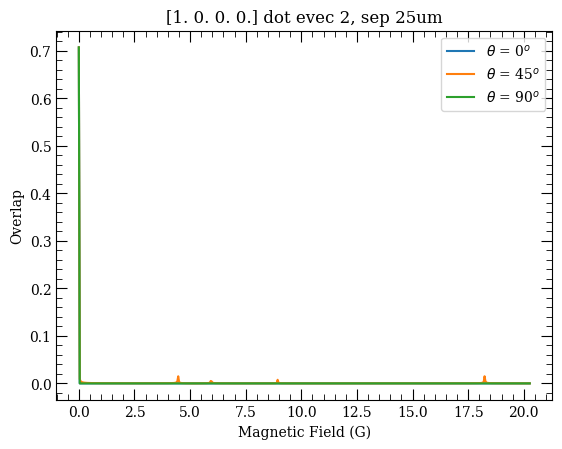

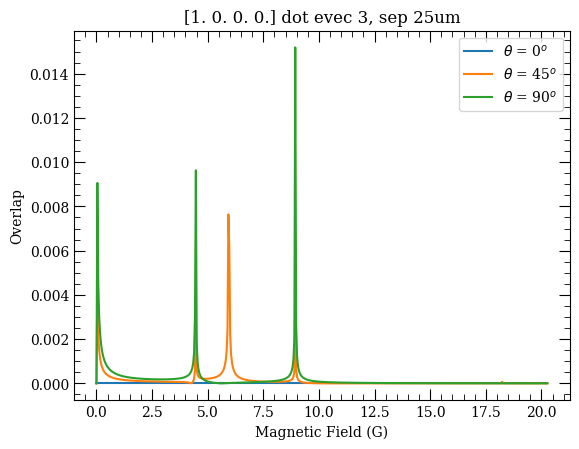

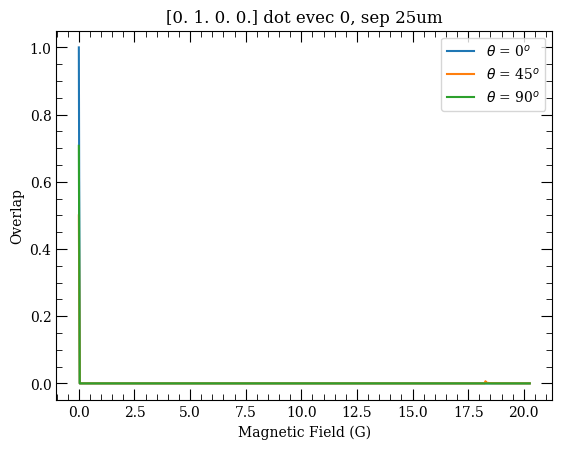

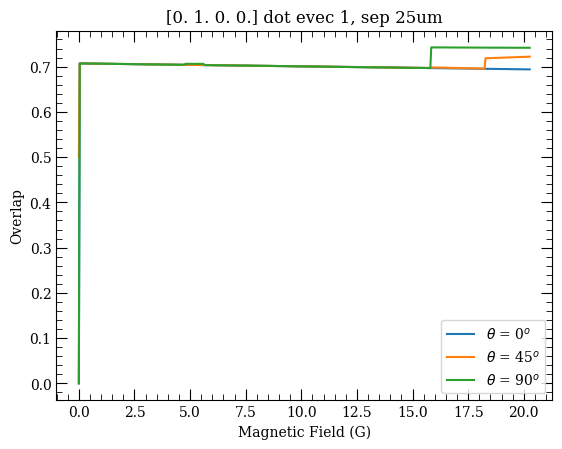

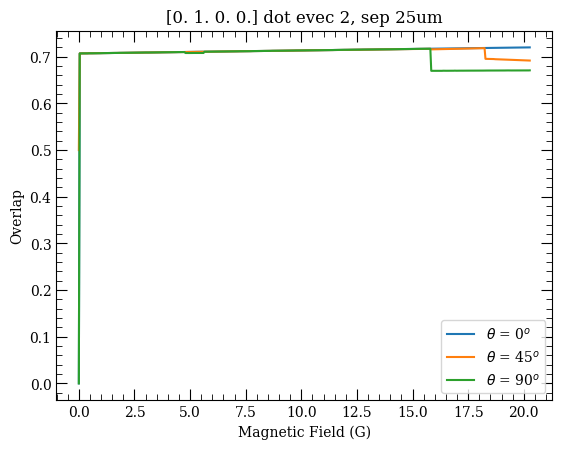

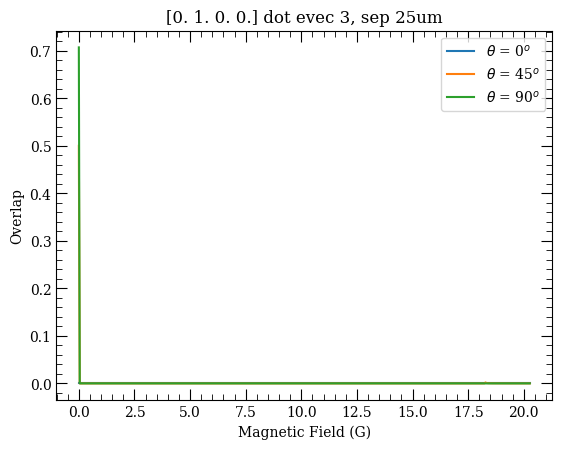

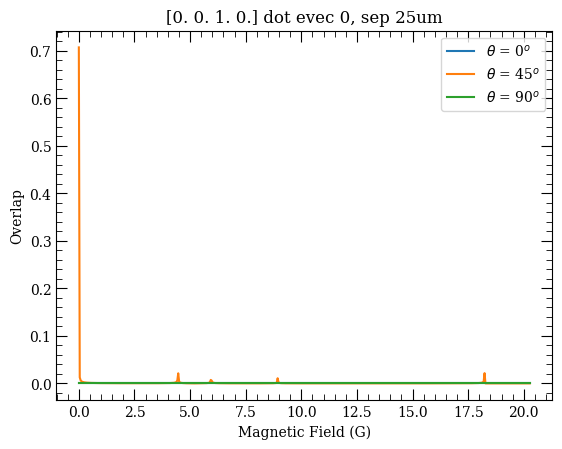

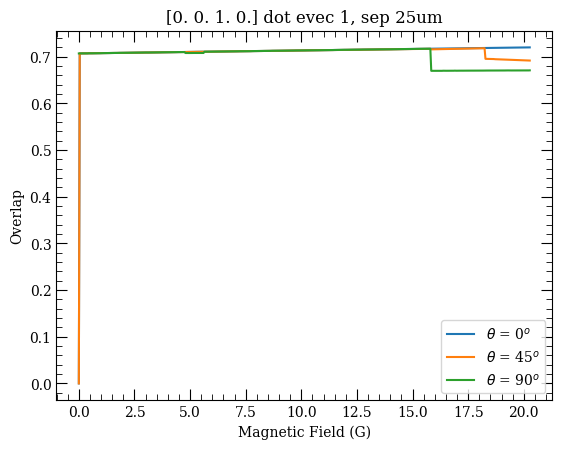

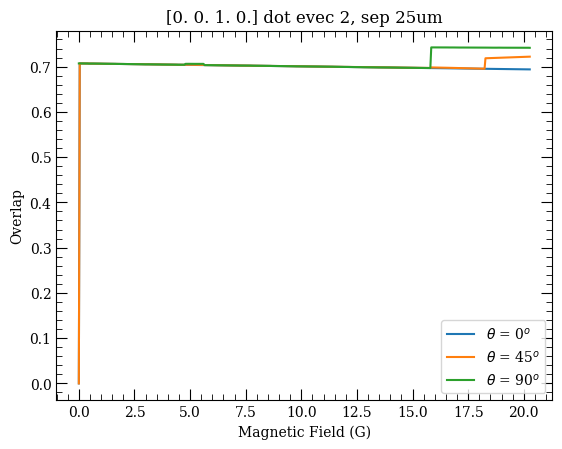

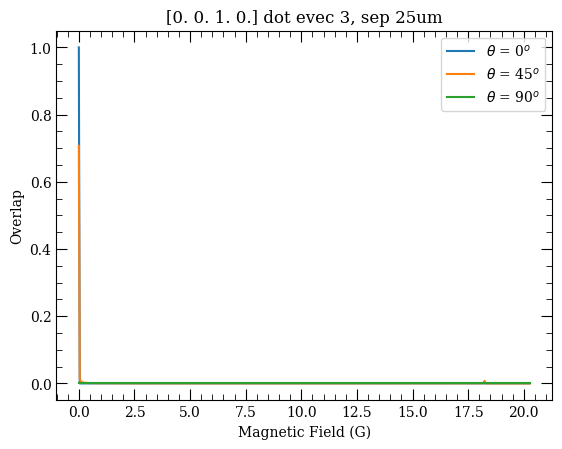

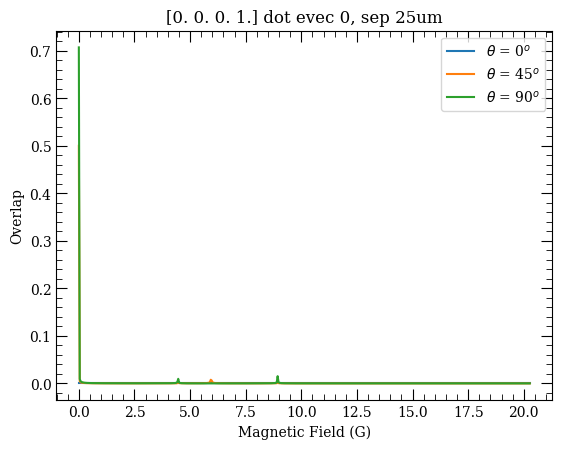

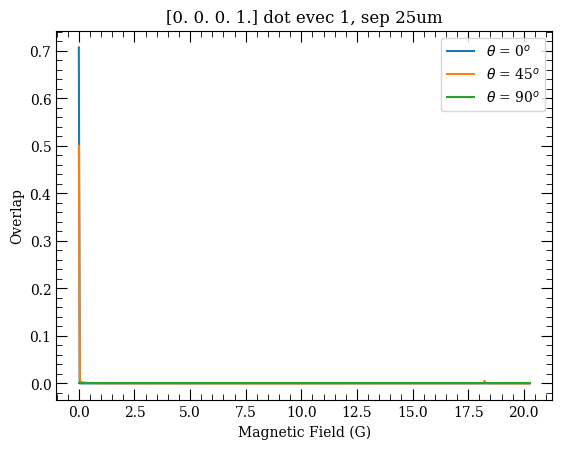

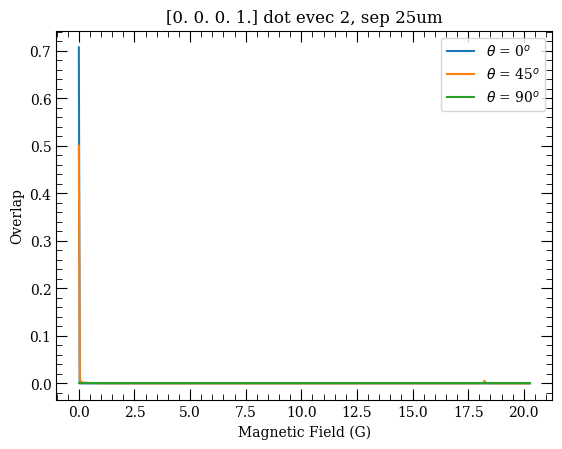

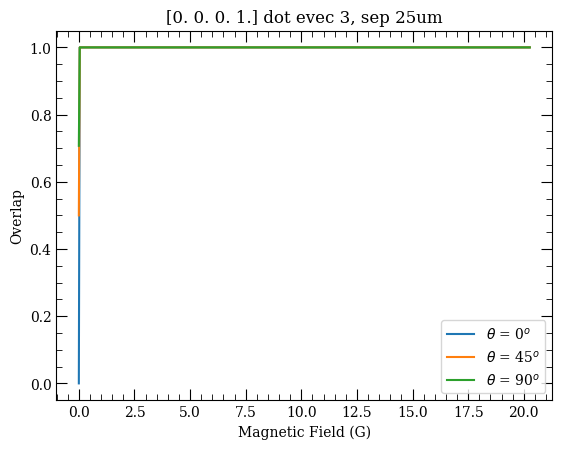

In [16]:
for i, ket in enumerate(ket_tuples):
    print(i, ket)

figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\magnetic\\target state hams\\'

if not os.path.exists(figpath + 'eigenenergies\\'):
    os.makedirs(figpath + 'eigenenergies\\')
if not os.path.exists(figpath + 'overlaps\\'):
    os.makedirs(figpath + 'overlaps\\')

tups = np.eye(len(ket_tuples))

overlap = {f'{r}{theta}' : {f'{index}{tup}' : [abs(np.dot(tup, evec[index])) for evec in evec_list[f'{r}{theta}']] for index in range(len(ket_tuples)) for tup in tups} for r in rs for theta in thetas}
Ediag = {f'{r}{theta}' : {f'{index}' : [eval[index] for eval in eval_list[f'{r}{theta}']] for index in range(len(ket_tuples))} for r in rs for theta in thetas}

r = 25

for index in range(len(ket_tuples)):
    fig, ax = plt.subplots()
    for theta in thetas:         
        ax.plot(bs[f'{r}{theta}'], abs(np.array(Ediag[f'{r}{theta}'][f'{index}'])), "-", label = fr'$\theta$ = {theta}$^o$')

    ax.legend()
    ax.set_title(f'{tuple0[0]} {tuple0[0]} --> \n {tuple1[0]} {tuple1[0]} index{index}, sep {r}um')
    ax.set_xlabel(r"Magnetic Field (G)")
    ax.set_ylabel(r"Energy (MHz)")

    plt.savefig(figpath + f'eigenenergies\\sep {r}um, e {np.round(e,1)}Vcm evec {index}.png')

plt.show()


for tup in tups:
    for index in range(len(ket_tuples)):
        fig, ax = plt.subplots()
        for theta in thetas:         
            ax.plot(bs[f'{r}{theta}'], overlap[f'{r}{theta}'][f'{index}{tup}'], label = fr'$\theta$ = {theta}$^o$') 
        ax.legend()
        ax.set_xlabel(r"Magnetic Field (G)")
        ax.set_ylabel(r"Overlap")
        ax.set_title(f'{tup} dot evec {index}, sep {r}um')
        
        plt.savefig(figpath + f'\\overlaps\\sep {r}um, e {np.round(e,1)}Vcm evec {index}.png')

0 (KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,-1/2))
1 (KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,1/2))
2 (KetAtom(Rb:59,S_1/2,1/2), KetAtom(Cs:57,S_1/2,-1/2))
3 (KetAtom(Rb:59,S_1/2,1/2), KetAtom(Cs:57,S_1/2,1/2))


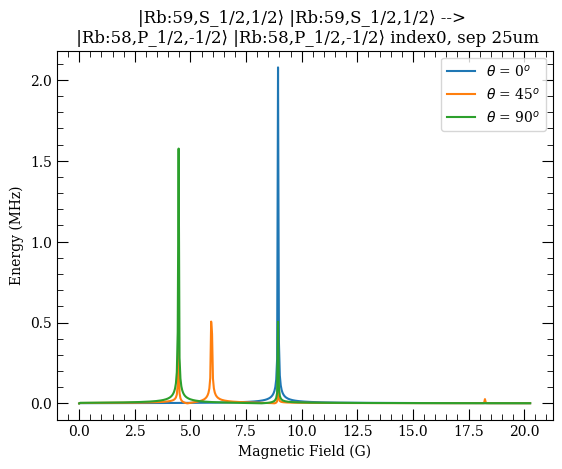

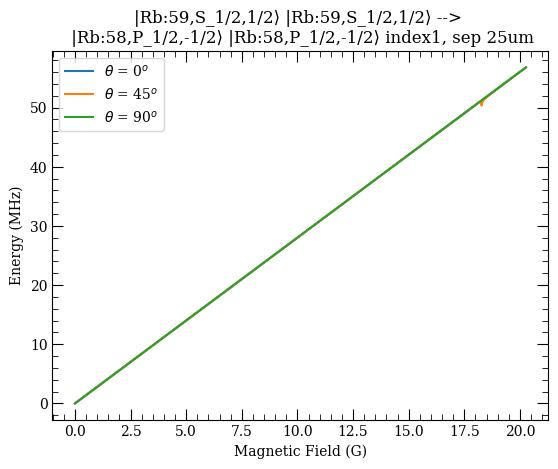

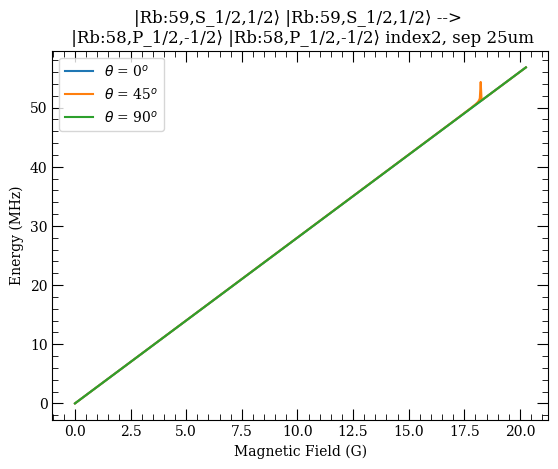

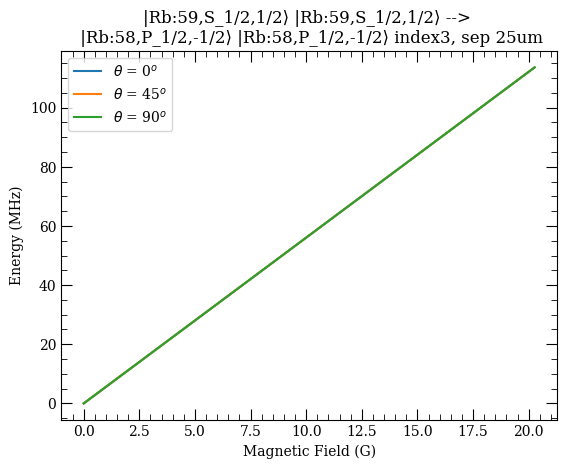

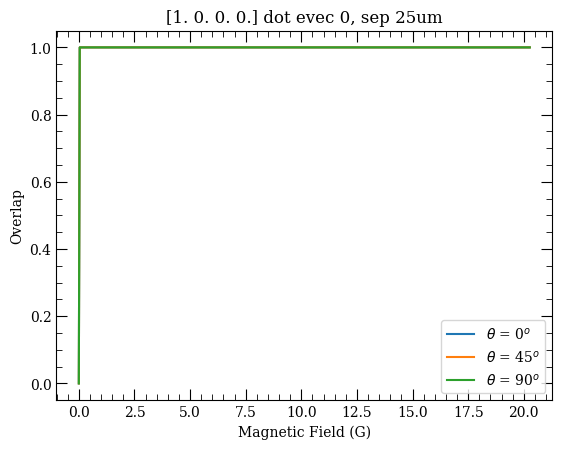

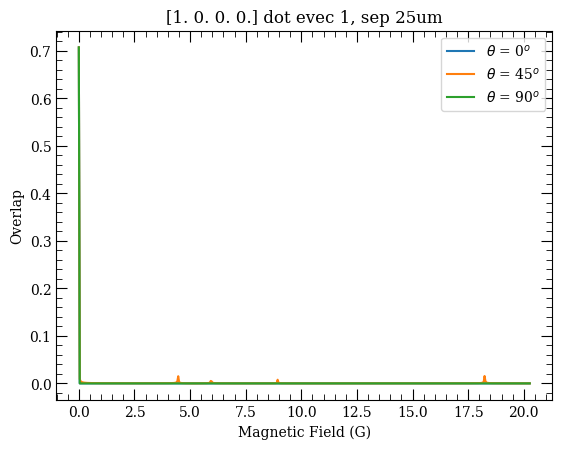

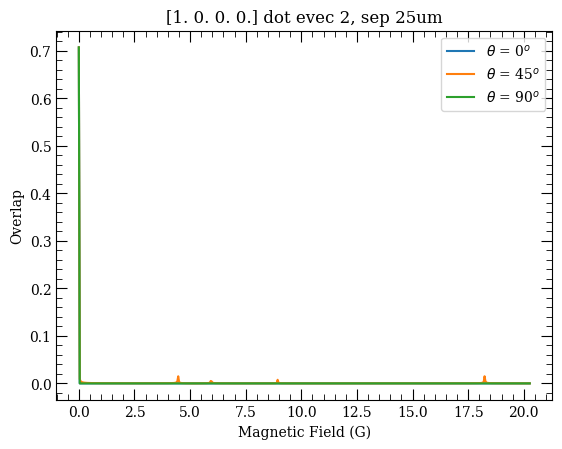

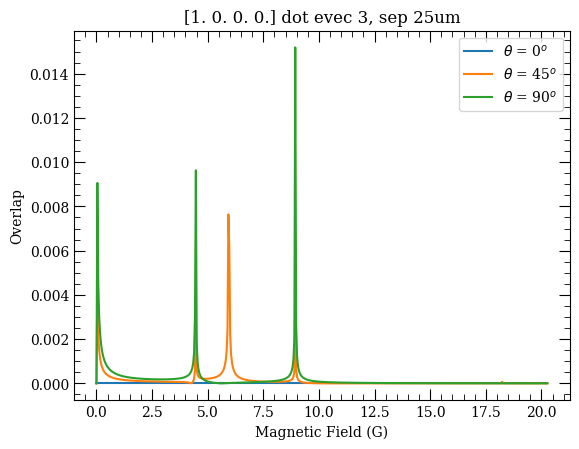

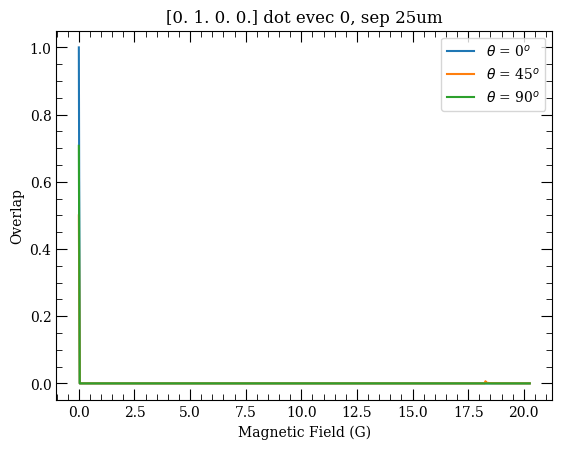

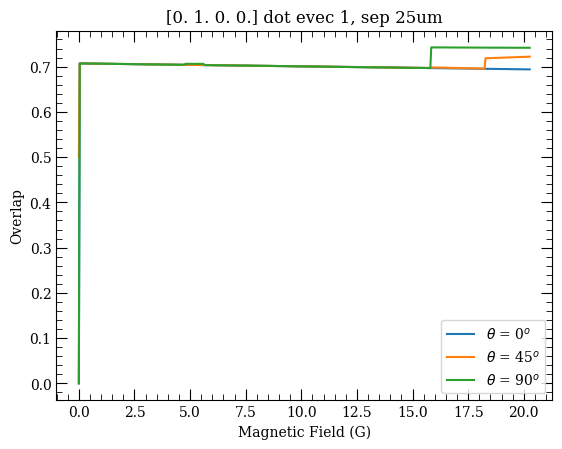

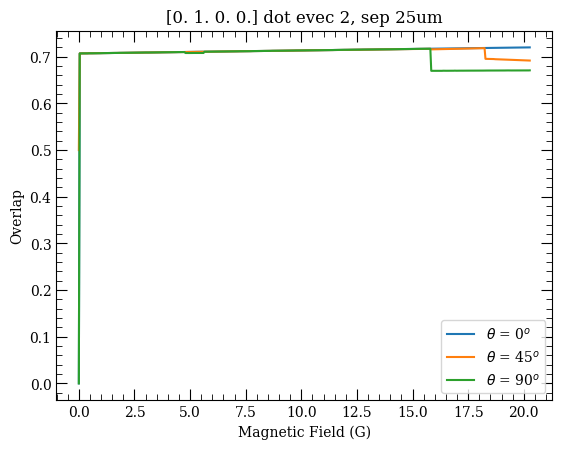

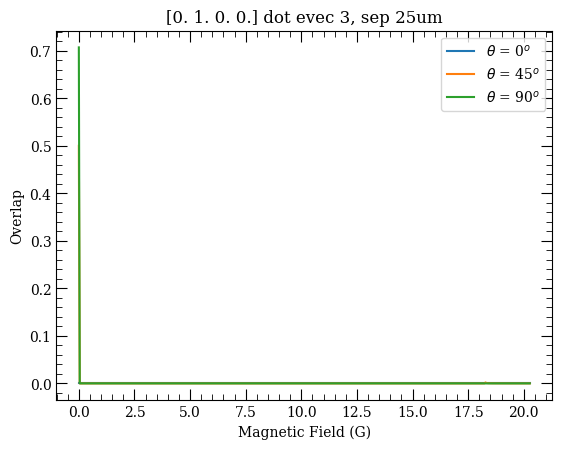

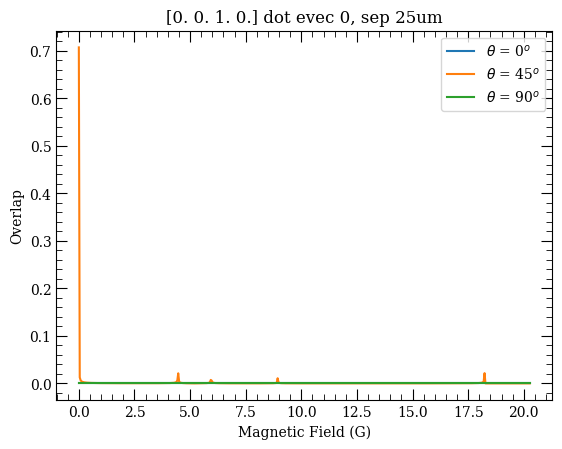

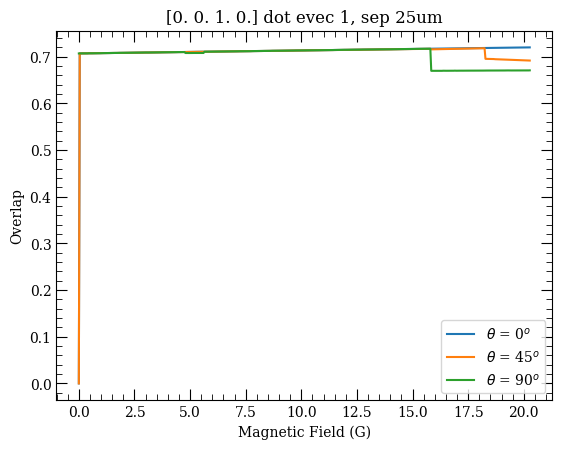

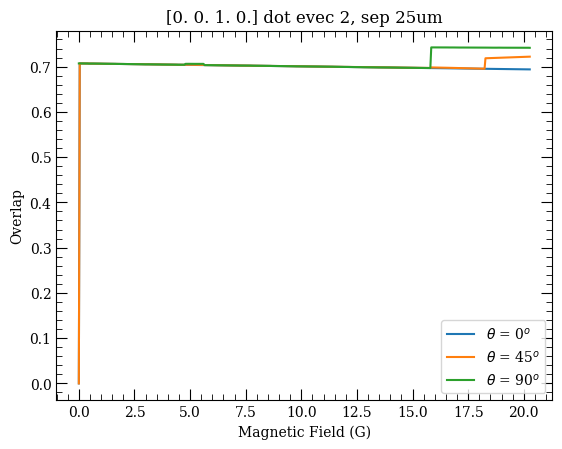

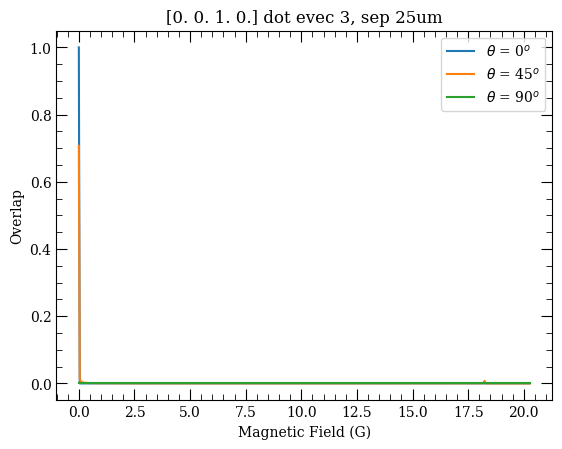

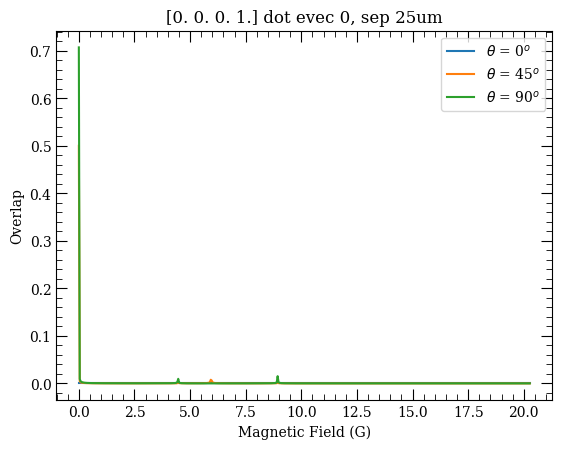

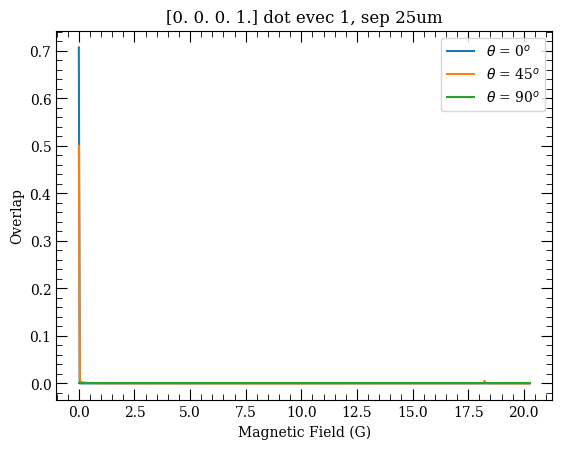

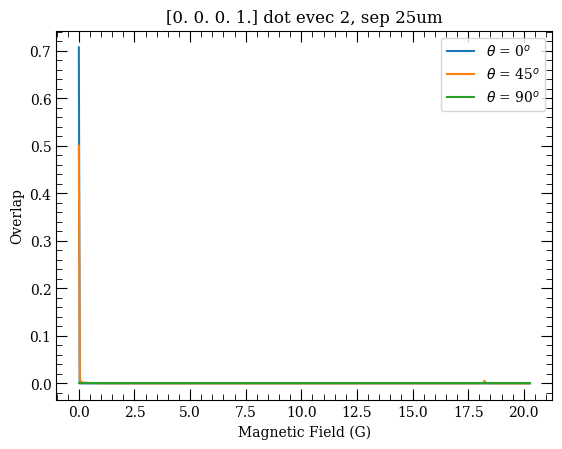

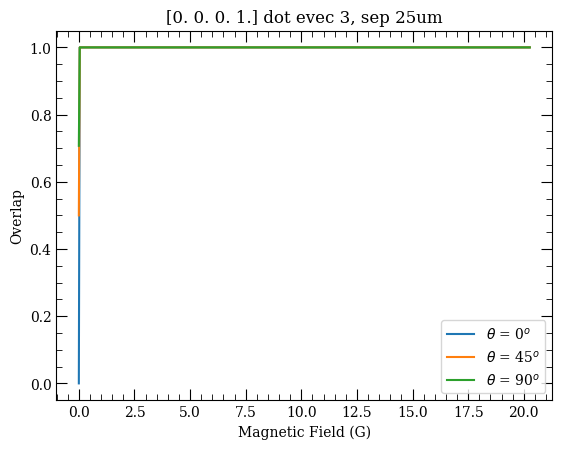

In [ ]:
for i, ket in enumerate(ket_tuples):
    print(i, ket)

figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\magnetic\\target state hams\\'

if not os.path.exists(figpath + 'eigenenergies\\'):
    os.makedirs(figpath + 'eigenenergies\\')
if not os.path.exists(figpath + 'overlaps\\'):
    os.makedirs(figpath + 'overlaps\\')

tups = np.eye(len(ket_tuples))

overlap = {f'{r}{theta}' : {f'{index}{tup}' : [abs(np.dot(tup, evec[index])) for evec in evec_list[f'{r}{theta}']] for index in range(len(ket_tuples)) for tup in tups} for r in rs for theta in thetas}
Ediag = {f'{r}{theta}' : {f'{index}' : [eval[index] for eval in eval_list[f'{r}{theta}']] for index in range(len(ket_tuples))} for r in rs for theta in thetas}

r = 25

for index in range(len(ket_tuples)):
    fig, ax = plt.subplots()
    for theta in thetas:         
        ax.plot(bs[f'{r}{theta}'], abs(np.array(Ediag[f'{r}{theta}'][f'{index}'])), "-", label = fr'$\theta$ = {theta}$^o$')

    ax.legend()
    ax.set_title(f'{tuple0[0]} {tuple0[0]} --> \n {tuple1[0]} {tuple1[0]} index{index}, sep {r}um')
    ax.set_xlabel(r"Magnetic Field (G)")
    ax.set_ylabel(r"Energy (MHz)")

    plt.savefig(figpath + f'eigenenergies\\sep {r}um, e {np.round(e,1)}Vcm evec {index}.png')

plt.show()


for tup in tups:
    for index in range(len(ket_tuples)):
        fig, ax = plt.subplots()
        for theta in thetas:         
            ax.plot(bs[f'{r}{theta}'], overlap[f'{r}{theta}'][f'{index}{tup}'], label = fr'$\theta$ = {theta}$^o$') 
        ax.legend()
        ax.set_xlabel(r"Magnetic Field (G)")
        ax.set_ylabel(r"Overlap")
        ax.set_title(f'{tup} dot evec {index}, sep {r}um')
        
        plt.savefig(figpath + f'\\overlaps\\sep {r}um, e {np.round(e,1)}Vcm evec {index}.png')

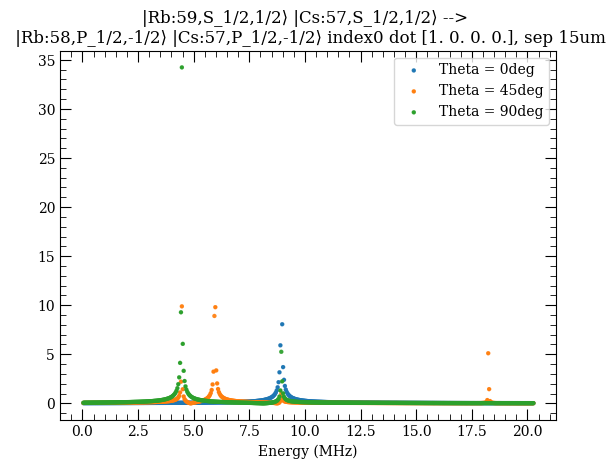

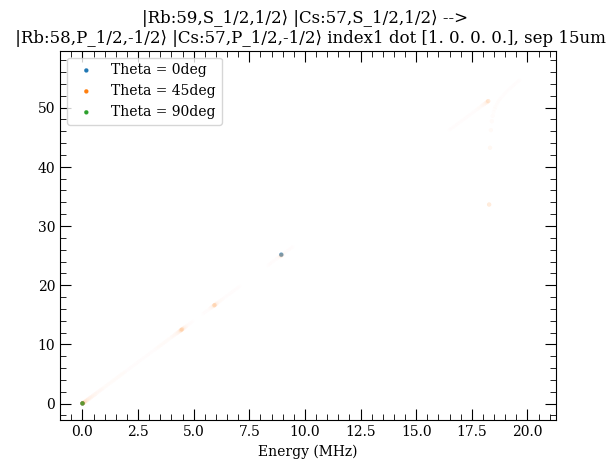

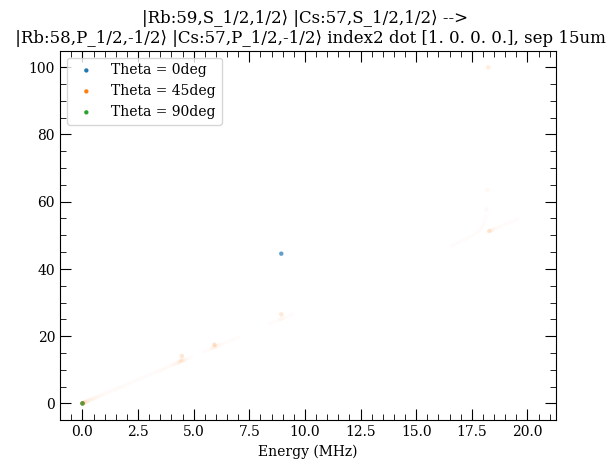

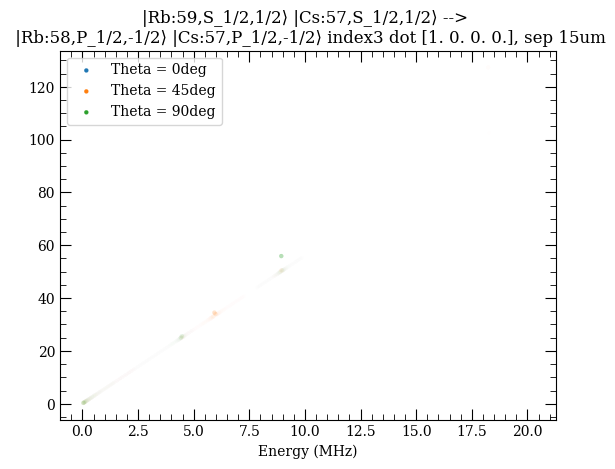

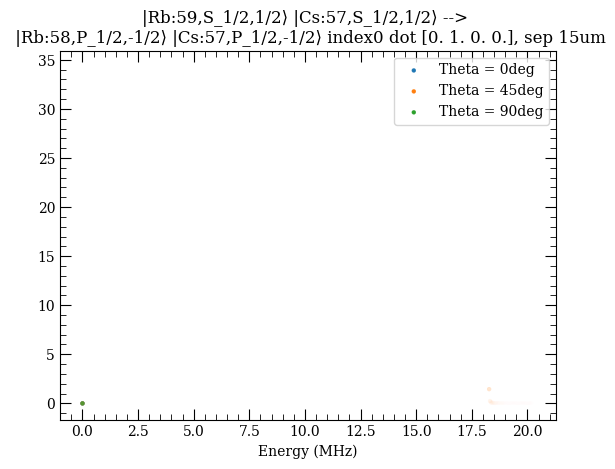

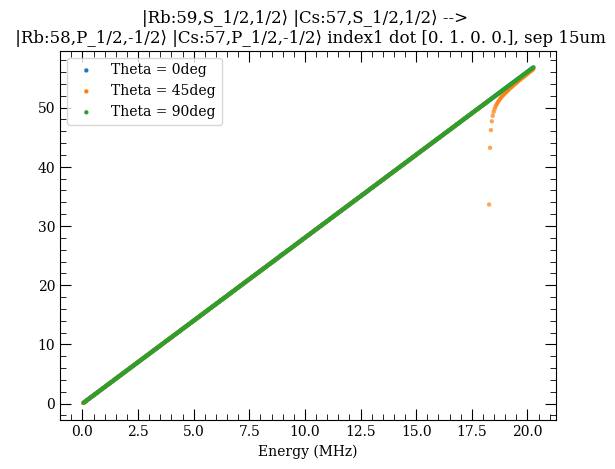

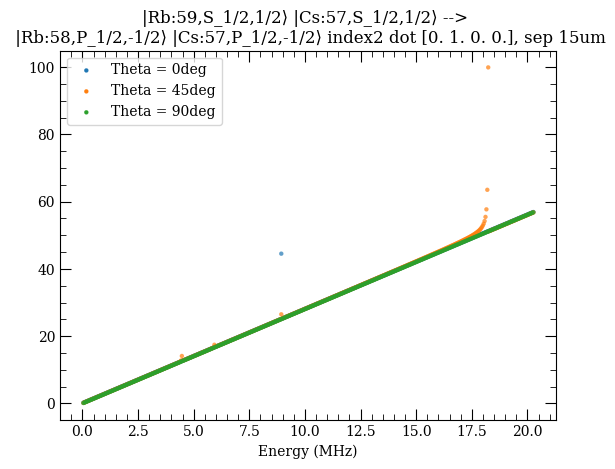

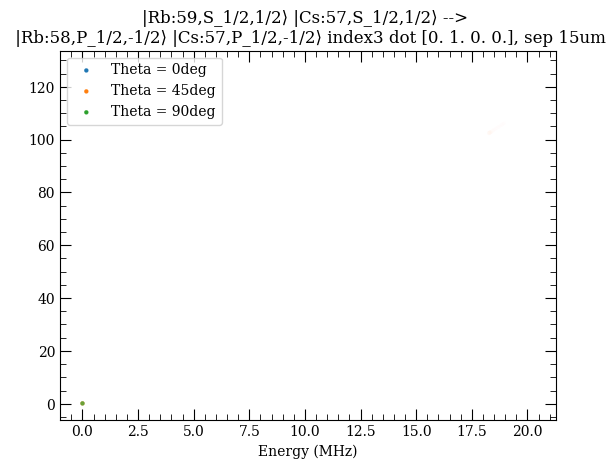

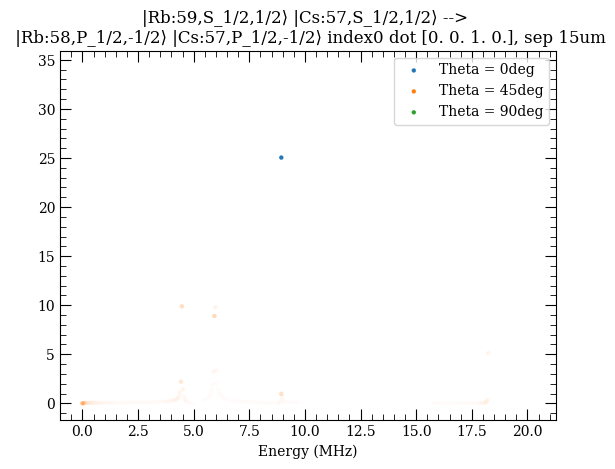

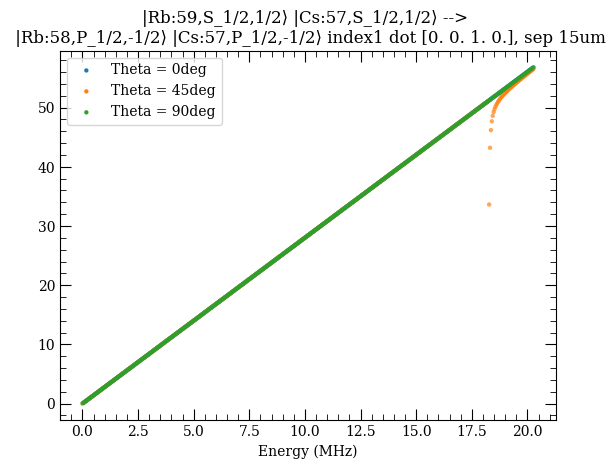

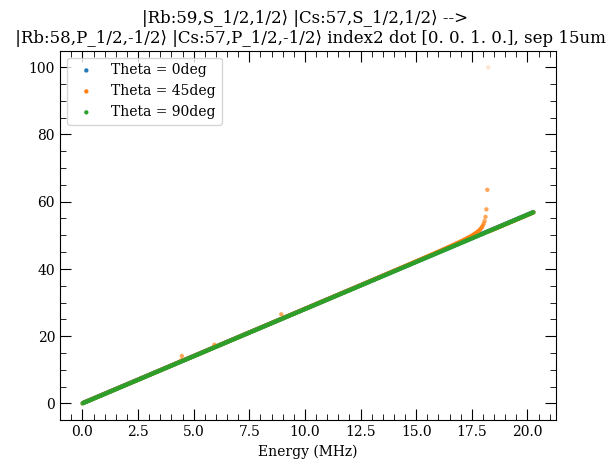

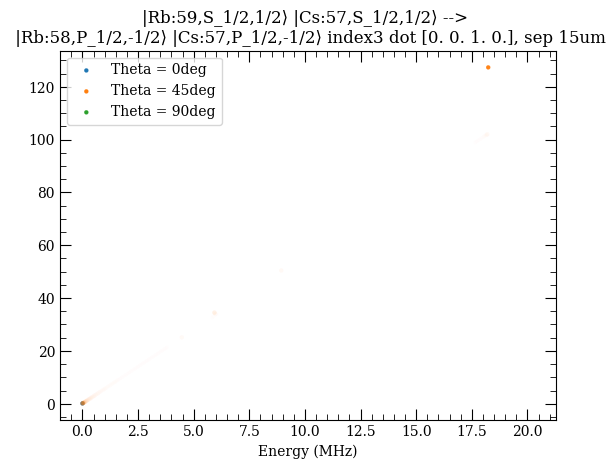

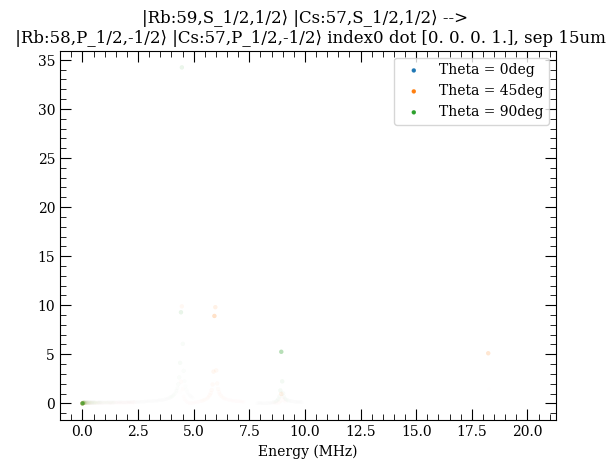

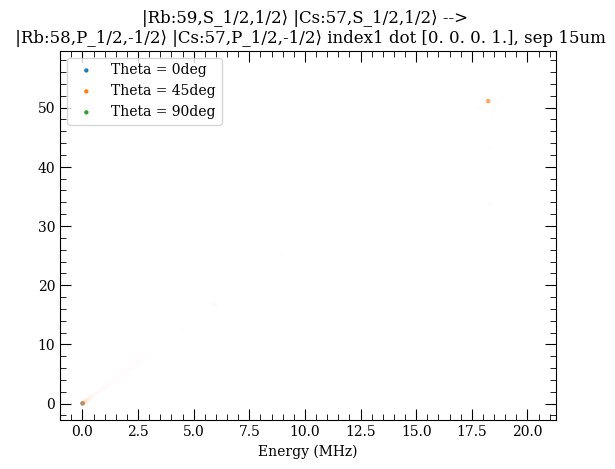

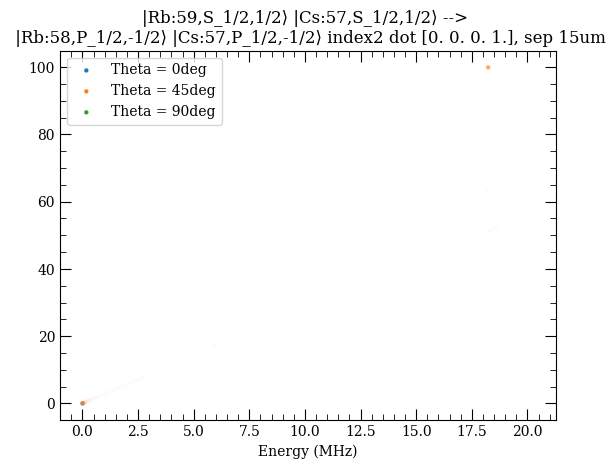

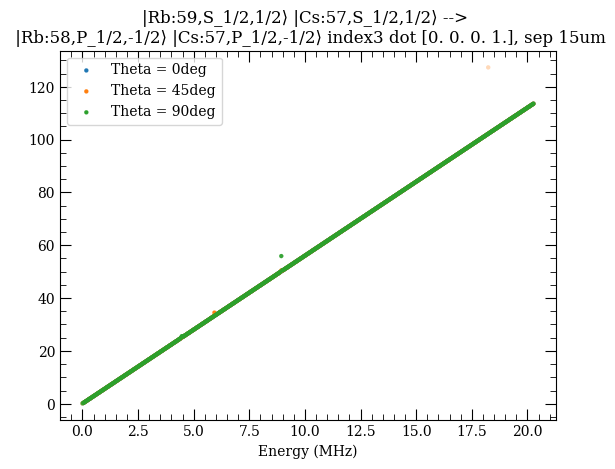

In [23]:
colours = ('orange', 'green', 'red', 'blue', 'purple')
prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']
if not os.path.exists(figpath + 'eigenenergies dots\\'):
    os.makedirs(figpath + 'eigenenergies dots\\')

for r in rs[2:3]:
    for tup in tups:
        for index in range(len(ket_tuples)):
            fig, ax = plt.subplots()
            for i, theta in enumerate(thetas):

                # 1. Convert the base color name to RGB (e.g., 'red' -> [1, 0, 0])
                base_rgb = mcolors.to_rgb(colours[i])
                
                # 2. Build the RGBA array: (N, 4)
                # This stores the specific relevance for every point in THIS set
                rgba = np.zeros((len(Ediag[f'{r}{theta}'][f'{index}']), 4))
                rgba[:, :3] = base_rgb
                rgba[:, 3] = overlap[f'{r}{theta}'][f'{index}{tup}']
                
                ax.scatter(bs[f'{r}{theta}'],
                        abs(np.array(Ediag[f'{r}{theta}'][f'{index}'])),
                        c=rgba,
                        marker='.',
                        linewidths=.1,
                        label = fr'Theta = {theta}deg')
                
            leg = plt.legend()
            for lh in leg.legend_handles:
                if lh is not None:  # Use 'is not None' instead of 'if lh:'
                    lh.set_alpha(1)
            ax.set_title(f'{tuple0[0]} {tuple0[1]} --> \n {tuple1[0]} {tuple1[1]} index{index} dot {tup}, sep {r}um')
            ax.set_xlabel(r"Energy (MHz)")
            plt.savefig(figpath + f'eigenenergies dots\\sep {r}um, e {np.round(e,1)}Vcm evec {index} dot tup.png')

        plt.show()
        plt.close()